# Helper Functions

In [1]:
from pathlib import Path

path_candidates = [
    "/kaggle/input/datasets/alecy333/v29-glycemic-preprocessed/kaggle/working",
    "/kaggle/input/notebooks/alecy333/glycemic-copy/",
    "/kaggle/input/datasets/alecy333/glycemia-processed",
    "/kaggle/working"
]

for pt in path_candidates:
    path = Path(pt)
    if path.exists():
        INPUT_BASE = path
        break

print(INPUT_BASE)

/kaggle/input/datasets/alecy333/v29-glycemic-preprocessed/kaggle/working


In [2]:
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
warnings.filterwarnings("ignore")

BASE = Path(
    "/kaggle/input/datasets/alecy333/big-ideas-glycemic-1-13/big-ideas-lab-glycemic-variability-and-wearable-device-data-1.1.3"
)

food3_cols = ['date', 'time', 'time_begin', 'logged_food', 'amount',
       'unit', 'searched_food', 'calorie', 'total_carb', 'dietary_fiber',
       'sugar', 'protein', 'total_fat']

# ---> FIX 1: Pass the global_t0 into the function <---
def to_relative_minutes(df, global_t0, time_col="Timestamp"):
    df = df.copy()
    df["minutes"] = (df[time_col] - global_t0).dt.total_seconds() / 60.0
    return df


def load_dexcom(pid: str) -> pd.DataFrame:
    fpath = BASE / pid / f"Dexcom_{pid}.csv"
    df = pd.read_csv(fpath, low_memory=False)
    df = df.rename(columns={
        "Timestamp (YYYY-MM-DDThh:mm:ss)": "Timestamp",
        "Glucose Value (mg/dL)":           "Glucose",
        "Event Type":                       "EventType"
    })
    df = df[df["EventType"] == "EGV"].copy()
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df["Glucose"]   = pd.to_numeric(df["Glucose"], errors="coerce")
    df = df.dropna(subset=["Timestamp", "Glucose"])
    df = df[["Timestamp", "Glucose"]].sort_values("Timestamp").reset_index(drop=True)
    # ---> FIX 2: Removed local relative minute conversion <---
    return df


def load_wearable(pid: str, signal: str) -> pd.DataFrame:
    fpath = BASE / pid / f"{signal}_{pid}.csv"
    if not fpath.exists():
        print(f"  WARNING: {fpath.name} not found")
        return None
    df = pd.read_csv(fpath)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={"datetime": "Timestamp"})
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)
    # ---> FIX 3: Removed local relative minute conversion <---
    return df

def load_participant(pid: str) -> dict:
    data = {}
    
    # 1. Load all raw data first
    data["Dexcom"] = load_dexcom(pid)
    for signal in ["EDA", "HR", "TEMP", "ACC"]:
        result = load_wearable(pid, signal)
        if result is not None:
            data[signal] = result
            
    # ---> FIX 4: Find the absolute Global t0 across all loaded devices <---
    t0_candidates = []
    for key, df in data.items():
        if df is not None and not df.empty and "Timestamp" in df.columns:
            #print(f"{key}: min={df['Timestamp'].min()}, dtype={df['Timestamp'].dtype}, nans={df['Timestamp'].isna().sum()}")
            t0_candidates.append(df["Timestamp"].min())
            
    global_t0 = min(t0_candidates) # The absolute earliest moment recording started
    
    # Apply the global_t0 to all physiological dataframes
    for key, df in data.items():
        if df is not None and not df.empty and "Timestamp" in df.columns:
            data[key] = to_relative_minutes(df, global_t0)
    # ----------------------------------------------------------------------
    
    # Food log
    food_path = BASE / pid / f"Food_Log_{pid}.csv"
    if food_path.exists():
        try:
            if pid == '003':
                food = pd.read_csv(food_path, names=food3_cols, header=None)
            else:            
                food = pd.read_csv(food_path)
            food.columns = food.columns.str.strip()
            
            if "time_begin" in food.columns:
                time_col = "time_begin"
            elif "time" in food.columns:
                time_col = "time"
            else:
                time_col = None
            
            if time_col:
                food[time_col] = pd.to_datetime(food[time_col], errors="coerce")
                # ---> FIX 5: Use the newly established global_t0 <---
                food["food_minutes"] = (food[time_col] - global_t0).dt.total_seconds() / 60.0
            
            data["Food"] = food
        except Exception as e:
            print(f"  Food log warning for {pid}: {e}")
    
    return data

In [3]:
def resample_to_1min(df, value_col, mask_below=None):
    """
    Convert irregular signal into 1-min averaged time series.
    ONLY produces signal-level representation (no feature engineering).
    """
    df = df.copy()

    if mask_below is not None:
        df.loc[df[value_col] < mask_below, value_col] = np.nan

    df["minute_bin"] = df["minutes"].astype(int)

    # ONLY MEAN (important simplification)
    resampled = df.groupby("minute_bin")[value_col].mean()

    return resampled


def build_minute_grid(d):
    """
    FIXED TO BE VECTORIZED NOW
    Unified 1-minute aligned dataset.
    Each column = raw physiological signal (NOT engineered features).
    """
    max_min = int(d["Dexcom"]["minutes"].max())

    grid = pd.DataFrame({"minute": np.arange(0, max_min + 1)})
    grid = grid.set_index("minute")

    # --- RECONSTRUCT GLOBAL T0 ---
    dexcom_first_timestamp = d["Dexcom"]["Timestamp"].min()
    dexcom_first_minute    = d["Dexcom"]["minutes"].min()
    global_t0 = dexcom_first_timestamp - pd.Timedelta(minutes=dexcom_first_minute)

    start_minutes_from_midnight = global_t0.hour * 60 + global_t0.minute
    grid["minutes_from_midnight"] = (start_minutes_from_midnight + grid.index) % 1440

    # --- PHYSIOLOGICAL SIGNALS ---
    gluc = (
        resample_to_1min(d["Dexcom"], "Glucose")
        .reindex(grid.index)
        .interpolate(method="linear", limit=15)
    )
    grid["glucose"] = gluc
    grid["hr"]   = resample_to_1min(d["HR"],   "hr")
    grid["eda"]  = resample_to_1min(d["EDA"],  "eda")
    grid["temp"] = resample_to_1min(d["TEMP"], "temp", mask_below=25)

    acc = d["ACC"].copy()
    acc["magnitude"] = np.sqrt(acc["acc_x"]**2 + acc["acc_y"]**2 + acc["acc_z"]**2)
    grid["acc"] = resample_to_1min(acc, "magnitude")

    # --- MEAL FEATURES (vectorized) ---
    grid["is_postprandial"] = 0
    grid["time_since_meal"] = 999.0
    grid["meal_event"]      = 0
    grid["carbs"]           = 0.0
    grid["sugar"]           = 0.0
    grid["protein"]         = 0.0
    grid["calories"]        = 0.0

    if "Food" in d and not d["Food"].empty:
        food_df = d["Food"]

        # 1. Filter to valid rows that fall within the grid
        valid = (
            food_df
            .dropna(subset=["food_minutes"])
            .copy()
        )
        valid["minute"] = valid["food_minutes"].astype(int)
        valid = valid[valid["minute"].isin(grid.index)]

        if not valid.empty:
            # 2. Macro accumulation — group by minute, sum everything in one shot
            #    fillna(0) handles rows where a macro column is missing
            macro_agg = (
                valid
                .assign(
                    total_carb=valid["total_carb"].fillna(0),
                    sugar=valid["sugar"].fillna(0),
                    protein=valid["protein"].fillna(0),
                    calorie=valid["calorie"].fillna(0),
                )
                .groupby("minute")
                .agg(
                    meal_event=("minute",    "count"),
                    carbs=     ("total_carb","sum"),
                    sugar=     ("sugar",     "sum"),
                    protein=   ("protein",   "sum"),
                    calories=  ("calorie",   "sum"),
                )
            )
            # Clip meal_event to binary and write back
            macro_agg["meal_event"] = 1
            grid.update(macro_agg)

            # 3. is_postprandial and time_since_meal — vectorized scan
            #    For each minute in the grid, find the most recent meal at or before it
            meal_minutes = np.sort(valid["minute"].unique())
            grid_idx     = grid.index.values  # numpy array, fast

            # searchsorted gives the index of the meal just before or at each grid minute
            pos = np.searchsorted(meal_minutes, grid_idx, side="right") - 1

            # pos == -1 means no meal has happened yet
            has_prior_meal = pos >= 0

            # time since the most recent meal
            last_meal_at = np.where(has_prior_meal, meal_minutes[np.maximum(pos, 0)], -999)
            time_since   = np.where(has_prior_meal, grid_idx - last_meal_at, 999)

            grid["time_since_meal"]  = time_since
            grid["is_postprandial"]  = ((time_since >= 0) & (time_since <= 120)).astype(int)

    # Cap time_since_meal at 180 min (assumes return to fasting baseline)
    grid["time_since_meal"] = grid["time_since_meal"].clip(upper=180)

    return grid

#personalized labels
# def build_labels_only(grid, prediction_horizon=30, std_multiplier=1.0, window_mins=1440, min_baseline_mins=360, stride=5):
#     # 1. The Trailing Baseline (Strictly PAST data, no leakage)
#     rolling_mean = grid['glucose'].rolling(window=window_mins, min_periods=min_baseline_mins).mean()
#     rolling_std  = grid['glucose'].rolling(window=window_mins, min_periods=min_baseline_mins).std()
    
#     dynamic_threshold = rolling_mean + (rolling_std * std_multiplier)
    
#     # 2. The Target Event (Strictly FUTURE data)
#     if prediction_horizon > 0:
#         window_size = int(prediction_horizon + 1)
#         forward_max = grid['glucose'].iloc[::-1].rolling(
#             window=window_size, 
#             min_periods=1
#         ).max().iloc[::-1]
#     else:
#         forward_max = grid['glucose']
        
#     # 3. Create the binary label
#     labels = (forward_max > dynamic_threshold).astype(int)
    
#     # 4. Clean up (Drop rows where we are still building the initial baseline)
#     valid_mask = labels.notna() & grid['glucose'].notna() & dynamic_threshold.notna()
    
#     records = pd.DataFrame({
#         "minute": grid.index[valid_mask],
#         "label": labels[valid_mask].values,
#         "current_glucose": grid.loc[valid_mask, 'glucose'].values,
#         "future_max_glucose": forward_max[valid_mask].values,
#         "dynamic_threshold": dynamic_threshold[valid_mask].values
#     })
    
#     # 5. THE STRIDE: Apply the decimation right before returning
#     # iloc[::stride] simply takes every Nth row.
#     records = records[records["minute"] % stride == 0].reset_index(drop=True)
    
#     return records

def build_labels_only(grid, prediction_horizon=30, rise_threshold=30, stride=5, min_future_points=3):
    """
    Hard Threshold (Non personalized). FIXED TO BE VECTORIZED. 
    Scans the grid and returns a dataframe of labels mapped to the exact minute.
    Vectorized: uses a reverse rolling max instead of a Python for-loop.
    """
    glucose = grid["glucose"]

    # forward_max[t] = max glucose in [t, t + prediction_horizon]
    # Achieved by reversing the series, rolling, then reversing back
    forward_max = (
        glucose[::-1]
        .rolling(window=prediction_horizon + 1, min_periods=min_future_points)
        .max()
        [::-1]
    )

    rise = forward_max - glucose

    labels = pd.DataFrame({
        "minute":           grid.index,
        "label":            (rise >= rise_threshold).astype(int),
        "rise_mg_dl":       rise,
        "future_max":       forward_max,
    })

    # Drop rows where glucose or future window was insufficient
    labels = labels.dropna(subset=["rise_mg_dl"])

    # Apply stride
    labels = labels[labels["minute"] % stride == 0].reset_index(drop=True)

    # Drop the last prediction_horizon minutes — the rolling window there
    # is right-padded with NaNs so forward_max underestimates the true future.
    # (The dropna above handles most of this, but be explicit.)
    max_valid_minute = grid.index.max() - prediction_horizon
    labels = labels[labels["minute"] <= max_valid_minute].reset_index(drop=True)

    return labels

In [4]:
def build_feature_matrix(grid, labels_df, tau=0, physio_windows=[120], food_windows=[120, 480, 1440]):
    """
    1. Shifts and rolls the perfect 1-minute grid.
    2. Merges with the sparse labels_df.
    """
    # Create a copy so we don't modify the cached master grid
    df = grid.copy()
    out = pd.DataFrame(index=df.index)

    #add physiological features
    modalities = {"hr": "hr", "eda": "eda", "temp": "temp", "acc": "acc"}

    for w in physio_windows:
        for mod, col in modalities.items():
            lag = tau if isinstance(tau, int) else tau.get(mod, 0)
            
            # Because 'df' is exactly 1-min spaced, shift(lag) correctly shifts by 'lag' minutes
            shifted = df[col].shift(lag)
            
            # Rolling over window_size minutes

            tolerance = 0.8
            min_req = int(tolerance*w)
            r = shifted.rolling(window=w, min_periods=min_req)
    
            out[f"{mod}_mean_{w}m"] = r.mean()
            out[f"{mod}_std_{w}m"]  = r.std()
            out[f"{mod}_max_{w}m"]  = r.max()
            
            # Slope calculation
            # slope = (value_at_t  -  value_at_(t - w + 1)) / (w - 1)
            end_val   = shifted  # the current value is the last in the window
            start_val = shifted.shift(w - 1)  # the first value in the window
            out[f"{mod}_slope_{w}m"] = (end_val - start_val) / (w - 1)

    blinding_lag = tau if isinstance(tau, int) else min(tau.values()) #heuristic lag added to nonphysiological features to prevent data leakage

    #add food columns
    food_cols = ["meal_event", "carbs", "sugar", "protein", "calories"]
    for col in food_cols:
        if col in df.columns:
            shifted = df[col].shift(blinding_lag)
            
            for w in food_windows:
                # min_periods=1 is crucial here! 
                # If we used 3, a single meal event surrounded by zeros would yield NaN.
                r = shifted.rolling(w, min_periods=1)
                
                if col == "meal_event":
                    out[f"Eatcnt_{w}m"] = r.sum()
                else:
                    out[f"{col}_{w}m"] = r.sum()

    #contextual columns
    context_cols = ["minutes_from_midnight", "is_postprandial", "time_since_meal"]
    for c in context_cols:
        if c in df.columns:
            out[c] = df[c].shift(blinding_lag)
            
    out = out.reset_index() # Pulls 'minute' out of the index to a column

    # MERGE: Only keep rows where we have a calculated label from our stride=5 process
    final_df = pd.merge(labels_df, out, on="minute", how="inner")
    
    # Drop rows where feature generation failed (e.g., due to the lag/window pushing into NaNs)
    feature_cols = [c for c in final_df.columns if c not in ["minute", "label", "rise_mg_dl"]]
    final_df = final_df.dropna(how="all", subset=feature_cols)

    return final_df

In [5]:
def create_master_data(prediction_horizon, exclude=[]):
    ALL_PIDS = [f"{i:03d}" for i in range(1, 17)]
    master_data = {} 
    
    for pid in ALL_PIDS:
        if pid in exclude:
            continue
        
        print(f"Processing {pid}...", end=" ")
        try:
            # 1. Load raw data and build the continuous 1-minute baseline
            grid_path = INPUT_BASE / f"{pid}_grid.csv"
            
            if grid_path.exists():
                grid = pd.read_csv(grid_path, index_col="minute")
            else:
                dp   = load_participant(pid)
                grid = build_minute_grid(dp)
                grid.to_csv(f"{pid}_grid.csv")
    
            # 2. Build ONLY the sparse targets (stride=5)
            # FIX: Dynamically name the cache file based on the horizon to prevent cross-contamination
            label_filename = f"{pid}_labels_h{prediction_horizon}.csv"
            labels_path = INPUT_BASE / label_filename
            
            if labels_path.exists():
                labels_df = pd.read_csv(labels_path)
            else:
                labels_df = build_labels_only(grid, prediction_horizon=prediction_horizon, rise_threshold=30)
                labels_df["pid"] = pid
                # Write to current working directory using the specific horizon filename
                labels_df.to_csv(label_filename, index=False)
            
            # 3. Store BOTH pieces in the master cache
            master_data[pid] = {
                "grid": grid,
                "labels": labels_df
            }      
            
            print(f"{len(labels_df)} samples, {labels_df['label'].mean():.1%} positive")
            
        except Exception as e:
            print(f"FAILED — {e}")

    return master_data

In [6]:
def build_full_dataset(master_data, tau=0, physio_windows=[120], food_windows=[120,480,1440], save_csv=True, filename=None, verbose=False):
    """
    Build feature-engineered dataset from master_data.

    Parameters
    ----------
    master_data : dict
        pid -> dictionary containing "grid" (continuous 1-min data) 
               and "labels" (sparse targets)

    tau : int or dict
        physiological lag
        tau could be a single int, or a dict of dicts

    window_size : int
        window length in minutes

    Returns
    -------
    full_dataset : pd.DataFrame
    """

    feature_tables = []

    for pid, data_dict in master_data.items():
        
        # 1. Unpack the decoupled grid and labels for this participant
        grid = data_dict["grid"]
        labels_df = data_dict["labels"]

        lags = tau if isinstance(tau, int) else tau.get(pid, {}) #if tau is a dict of pid:dict of lags, grab the corresponding lag dict.
        
        # 2. Pass both into the updated feature matrix builder
        feat_df = build_feature_matrix(
            grid=grid,
            labels_df=labels_df,
            tau=lags,
            physio_windows=physio_windows,
            food_windows=food_windows
        )

        idx = int(pid)

        patient_row = demo_df[demo_df["ID"] == idx]
        if not patient_row.empty:
            hba1c_val = patient_row["HbA1c"].values[0]
            gender_str = str(patient_row["Gender"].values[0]).strip().upper()
            
            feat_df["hba1c"] = hba1c_val
            feat_df["sex"] = 1 if gender_str == "MALE" else 0
        else:
            # Fallback if a patient is missing from the demographics file
            feat_df["hba1c"] = np.nan
            feat_df["sex"] = np.nan
        feat_df["pid"] = pid

        feature_tables.append(feat_df)

    full_dataset = pd.concat(
        feature_tables,
        ignore_index=True
    )

    if save_csv:
        if filename is None:
            if isinstance(tau, dict):
                filename = "full_dataset_modality_lag.csv"
            else:
                filename = f"full_dataset_tau_{tau}.csv"

        full_dataset.to_csv(filename, index=False)

    if verbose:
        print(f"\nTotal samples: {len(full_dataset):,}")
        print(
            f"Participants: "
            f"{full_dataset['pid'].nunique()}"
        )
        print(
            f"Overall positive: "
            f"{full_dataset['label'].mean():.1%}"
        )
    
        print(
            full_dataset.groupby("pid")["label"]
            .agg(["count", "mean"])
            .rename(
                columns={
                    "count": "samples",
                    "mean": "pos_rate"
                }
            )
            .round(3)
            .to_string()
        )

    return full_dataset

In [7]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

def run_loso(dataset, feature_cols, model, scale=True, verbose=False, smote=False):
    """
    dataset:
        concatenated feature dataframe
        already contains engineered features

    model:
        sklearn-style estimator supporting
        fit() and predict_proba()

    feature_cols:
        columns to use as predictors
    """

    all_pids = dataset["pid"].unique()

    y_true_all = []
    y_prob_all = []
    per_pid_auc = {}

    fold_importances = np.zeros(len(feature_cols))
    all_importances = []
    
    for test_pid in all_pids:
        if verbose:
            print(f"Leave one out -- test_pid for this iteration: {test_pid}")
        train = dataset[dataset["pid"] != test_pid]
        test  = dataset[dataset["pid"] == test_pid]

        train = train.dropna(subset=feature_cols)
        test  = test.dropna(subset=feature_cols)

        if verbose:
            print(f"Train set length: {len(train)}")
            print(f"Test set length: {len(test)}")
        
        if len(train) == 0 or len(test) == 0:
            print("no valid train or test set")
            print(f"length of train: {len(train)}")
            print(f"length of test: {len(train)}")
            continue

        X_train = train[feature_cols].values
        y_train = train["label"].values
        X_test = test[feature_cols].values
        y_test = test["label"].values

        if isinstance(model, XGBClassifier):
            ratio = (y_train == 0).sum() / (y_train == 1).sum()
            model.set_params(scale_pos_weight=ratio)

        if y_train.sum() >= 6 and smote:
            sm = SMOTE(random_state=42, k_neighbors=5)
            X_train, y_train = sm.fit_resample(X_train, y_train)
            if verbose:
                print(f"Smote used. New dataset size: {len(X_train)}")
                print(f"New positive ratio: {(y_train == 0).sum() / len(y_train)}")
                
        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)

        all_importances.append(model.feature_importances_)
        
        y_prob = model.predict_proba(X_test)[:, 1]

        # if test_pid == "015":
        #     print(f"\n--- DEEP DIVE PATIENT 015 ---")
        #     print(f"Total Test Rows: {len(y_test)}")
        #     print(f"True Spikes (y_test sum): {y_test.sum()}")
        #     print(f"Predicted Probs for Spikes: {y_prob[y_test == 1]}")
        #     print("-----------------------------\n")

        y_true_all.extend(y_test)
        y_prob_all.extend(y_prob)

        if len(np.unique(y_test)) > 1:
            per_pid_auc[test_pid] = roc_auc_score(
                y_test,
                y_prob
            )
    
    return (
        np.array(y_true_all),
        np.array(y_prob_all),
        per_pid_auc,
        all_importances
    )

# Data Loading and Preprocessing

In [8]:
demo_df = pd.read_csv("/kaggle/input/datasets/alecy333/big-ideas-glycemic-1-13/big-ideas-lab-glycemic-variability-and-wearable-device-data-1.1.3/Demographics.csv")
demo_df = demo_df.sort_values(by="ID")
demo_df.reset_index(drop=True)

,ID,Gender,HbA1c
0,1,FEMALE,5.5
1,2,MALE,5.6
2,3,FEMALE,5.9
3,4,FEMALE,6.4
4,5,FEMALE,5.7
5,6,FEMALE,5.8
6,7,FEMALE,5.3
7,8,FEMALE,5.6
8,9,MALE,6.1
9,10,FEMALE,6.0


In [9]:
#build feature columns
FEATURE_COLS = []
demographics = ["sex", "hba1c"]
FEATURE_COLS.extend(demographics)
context_cols = ["minutes_from_midnight", "is_postprandial", "time_since_meal"]
food_cols = ["meal_event", "carbs", "sugar", "protein", "calories"]

FEATURE_COLS.extend(context_cols)

physio_windows = [15, 30, 120, 360] #changed to shorter windows  
food_windows = [120, 480, 1440] #from Bent 2021

modalities = {"hr": "hr", "eda": "eda", "temp": "temp", "acc": "acc"}
#f"{mod}_mean_{w}m"

physio_cols = []

for w in physio_windows:
    for mod in modalities.keys():
        physio_cols.append(f"{mod}_mean_{w}m")
        physio_cols.append(f"{mod}_std_{w}m")
        physio_cols.append(f"{mod}_max_{w}m")
        physio_cols.append(f"{mod}_slope_{w}m")
FEATURE_COLS.extend(physio_cols)

food_feats = []

for w in food_windows:
    for col in food_cols:
        if col == "meal_event":
            food_feats.append(f"Eatcnt_{w}m")
        else:
            food_feats.append(f"{col}_{w}m")

FEATURE_COLS.extend(food_feats)

print(FEATURE_COLS)
print(f"Number of Features: {len(FEATURE_COLS)}")

['sex', 'hba1c', 'minutes_from_midnight', 'is_postprandial', 'time_since_meal', 'hr_mean_15m', 'hr_std_15m', 'hr_max_15m', 'hr_slope_15m', 'eda_mean_15m', 'eda_std_15m', 'eda_max_15m', 'eda_slope_15m', 'temp_mean_15m', 'temp_std_15m', 'temp_max_15m', 'temp_slope_15m', 'acc_mean_15m', 'acc_std_15m', 'acc_max_15m', 'acc_slope_15m', 'hr_mean_30m', 'hr_std_30m', 'hr_max_30m', 'hr_slope_30m', 'eda_mean_30m', 'eda_std_30m', 'eda_max_30m', 'eda_slope_30m', 'temp_mean_30m', 'temp_std_30m', 'temp_max_30m', 'temp_slope_30m', 'acc_mean_30m', 'acc_std_30m', 'acc_max_30m', 'acc_slope_30m', 'hr_mean_120m', 'hr_std_120m', 'hr_max_120m', 'hr_slope_120m', 'eda_mean_120m', 'eda_std_120m', 'eda_max_120m', 'eda_slope_120m', 'temp_mean_120m', 'temp_std_120m', 'temp_max_120m', 'temp_slope_120m', 'acc_mean_120m', 'acc_std_120m', 'acc_max_120m', 'acc_slope_120m', 'hr_mean_360m', 'hr_std_360m', 'hr_max_360m', 'hr_slope_360m', 'eda_mean_360m', 'eda_std_360m', 'eda_max_360m', 'eda_slope_360m', 'temp_mean_360m', 

In [10]:
print("Creating the master dictionary...")
master_data = create_master_data(prediction_horizon=30) #NO prediction horizon. predict EXACTLY at time t. 

Creating the master dictionary...
Processing 001... 2557 samples, 3.6% positive
Processing 002... 2114 samples, 6.2% positive
Processing 003... 2297 samples, 3.6% positive
Processing 004... 2161 samples, 3.6% positive
Processing 005... 2553 samples, 2.4% positive
Processing 006... 2840 samples, 5.6% positive
Processing 007... 2202 samples, 3.2% positive
Processing 008... 2508 samples, 5.1% positive
Processing 009... 2301 samples, 4.6% positive
Processing 010... 2145 samples, 8.0% positive
Processing 011... 2839 samples, 4.6% positive
Processing 012... 2169 samples, 4.5% positive
Processing 013... 1972 samples, 6.5% positive
Processing 014... 2233 samples, 6.2% positive
Processing 015... 1673 samples, 2.3% positive
Processing 016... 2274 samples, 6.1% positive


In [11]:
for pid, data in master_data.items():
    food = data["grid"]["meal_event"].sum()
    spikes = master_data[pid]["labels"]["label"].sum()
    print(f"{pid}: meal_events={food:.0f}, spikes={spikes:.0f}")

001: meal_events=44, spikes=92
002: meal_events=49, spikes=132
003: meal_events=29, spikes=83
004: meal_events=24, spikes=78
005: meal_events=44, spikes=62
006: meal_events=46, spikes=159
007: meal_events=36, spikes=71
008: meal_events=30, spikes=128
009: meal_events=52, spikes=106
010: meal_events=76, spikes=172
011: meal_events=45, spikes=131
012: meal_events=83, spikes=98
013: meal_events=59, spikes=129
014: meal_events=40, spikes=138
015: meal_events=46, spikes=39
016: meal_events=22, spikes=138


In [12]:
def make_rf():
    return RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

def make_xgb():
    return XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    )

In [13]:
import numpy as np
from scipy.stats import bootstrap

def calculate_bootstrap(per_pid_auc):
    data = list(per_pid_auc.values())
    data = (data,)
    
    res = bootstrap(data, np.mean, confidence_level=0.95, random_state=42)
    
    # 4. View results
    print(f"Lower Bound: {res.confidence_interval.low:.4f}")
    print(f"Upper Bound: {res.confidence_interval.high:.4f}")
    return res

In [14]:
all_aucrocs = {} #experiment_name: per_pid_auc dict

# Experiment A -- ZERO LAG BASELINE

## Create the Zero Lag Baseline Dataframe

In [15]:
print("Building dataset (tau = 0)...")
filename = "full_data_exp_a_h30.csv"
no_lag_full_path = INPUT_BASE / filename

if no_lag_full_path.exists():
    print("path exists, loading cached data...")
    full_data_no_lag = pd.read_csv(no_lag_full_path)
else:
    print("creating full labeled dataset...")
    full_data_no_lag = build_full_dataset(
        master_data,
        tau=0,
        physio_windows=physio_windows,
        food_windows=food_windows,
        filename=filename,
        verbose=True
    )

print(f"[INFO] Dataset shape: {full_data_no_lag.shape}")
print(f"[INFO] Positive rate: {full_data_no_lag['label'].mean():.3f}")
print(f"[INFO] Participants: {full_data_no_lag['pid'].nunique()}")

missing = [c for c in FEATURE_COLS if c not in full_data_no_lag.columns]
print(f"\n[CHECK] Missing features: {missing}")

full_data_no_lag

Building dataset (tau = 0)...
creating full labeled dataset...

Total samples: 36,838
Participants: 16
Overall positive: 4.8%
     samples  pos_rate
pid                   
001     2557     0.036
002     2114     0.062
003     2297     0.036
004     2161     0.036
005     2553     0.024
006     2840     0.056
007     2202     0.032
008     2508     0.051
009     2301     0.046
010     2145     0.080
011     2839     0.046
012     2169     0.045
013     1972     0.065
014     2233     0.062
015     1673     0.023
016     2274     0.061
[INFO] Dataset shape: (36838, 89)
[INFO] Positive rate: 0.048
[INFO] Participants: 16

[CHECK] Missing features: []


,minute,label,rise_mg_dl,future_max,pid,hr_mean_15m,hr_std_15m,hr_max_15m,hr_slope_15m,eda_mean_15m,...,protein_480m,protein_1440m,calories_120m,calories_480m,calories_1440m,minutes_from_midnight,is_postprandial,time_since_meal,hba1c,sex
0,115,0,7.4,68.0,001,77.304156,8.991288,97.498833,-1.289333,0.264320,...,0.0,0.0,0.0,0.0,0.0,1043,0,180,5.5,0
1,120,0,9.2,68.0,001,76.316278,5.508860,85.161500,0.745321,0.481799,...,0.0,0.0,0.0,0.0,0.0,1048,0,180,5.5,0
2,125,0,9.8,68.0,001,76.262100,6.945471,87.831833,0.427167,0.527685,...,0.0,0.0,0.0,0.0,0.0,1053,0,180,5.5,0
3,130,0,8.2,68.0,001,77.906967,7.493576,87.831833,0.376976,0.995639,...,0.0,0.0,0.0,0.0,0.0,1058,0,180,5.5,0
4,135,0,9.4,73.2,001,76.180511,6.801139,87.831833,-0.719393,1.329848,...,0.0,0.0,0.0,0.0,0.0,1063,0,180,5.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36833,11515,0,0.0,132.0,016,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,564,0,180,5.5,1
36834,11520,0,0.0,131.2,016,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,569,0,180,5.5,1
36835,11525,0,0.0,126.4,016,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,574,0,180,5.5,1
36836,11530,0,0.0,118.6,016,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,579,0,180,5.5,1


In [16]:
labels = master_data["001"]["labels"]
spike_minutes = labels[labels["label"] == 1]["minute"].values
print(spike_minutes[:20])

[ 145  150  155  160  165  170  175 1695 1700 1705 2885 2890 2895 2900
 2905 3800 3805 3810 3815 3820]


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pandas as pd


def plot_lag_window_figure(
    grid,
    t_pred,
    delta_T=30,
    w=30,
    lag=15,
    save_path="figure1_lag_window",
    figsize=(3.5, 3.6),
):

    x_lo = t_pred - w - lag - 25
    x_hi = t_pred + delta_T + 35
    mask = (grid.index >= x_lo) & (grid.index <= x_hi)

    t       = grid.index[mask].values
    glucose = grid.loc[mask, "glucose"].values
    hr      = grid.loc[mask, "hr"].values

    win_shifted_start = t_pred - lag - w
    win_shifted_end   = t_pred - lag
    win_zero_start    = t_pred - w
    win_zero_end      = t_pred

    horizon_mask = (t >= t_pred) & (t <= t_pred + delta_T)
    if horizon_mask.any():
        spike_idx_local = np.nanargmax(glucose[horizon_mask])
        spike_t   = t[horizon_mask][spike_idx_local]
        spike_val = glucose[horizon_mask][spike_idx_local]
    else:
        spike_t, spike_val = t_pred + delta_T / 2, np.nanmax(glucose)

    # ── Colours ───────────────────────────────────────────────────────────────
    C_GLUCOSE   = "#2166ac"
    C_HR        = "#d6604d"
    C_HORIZON   = "#92c5de"
    C_WIN_SHIFT = "#f4a582"
    C_WIN_ZERO  = "#aac8e0"
    C_SPIKE_DOT = "#b2182b"
    C_VLINE     = "#333333"
    C_W         = "#c04a10"
    C_TAU       = "#444444"
    C_DT        = "#1a6fa8"

    ALPHA_FILL  = 0.32
    ALPHA_FILL2 = 0.28
    LW_SIG      = 1.3
    LW_ANN      = 1.0
    FS_LABEL    = 10 #made a little bigger
    FS_ANNOT    = 10.5
    FS_AXIS     = 9.5

    outline = [pe.withStroke(linewidth=2.5, foreground="white")]

    plt.rcParams['font.family'] = 'sans-serif'

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"hspace": 0.12}
    )

    # ══════════════════════════════════════════════════════════════════════════
    # TOP PANEL — Glucose
    # ══════════════════════════════════════════════════════════════════════════
    ax1.plot(t, glucose, color=C_GLUCOSE, lw=LW_SIG, zorder=3,
             label="Glucose (mg/dL)")
    ax1.axvspan(t_pred, t_pred + delta_T,
                alpha=ALPHA_FILL, color=C_HORIZON, zorder=1,
                label=f"Prediction horizon $\\Delta T={delta_T}$ min")
    ax1.scatter(spike_t, spike_val,
                color=C_SPIKE_DOT, s=35, zorder=5,
                label="Glucose spike ($y=1$)")
    ax1.axvline(t_pred, color=C_VLINE, lw=LW_ANN, ls="--", zorder=4)

    g_min   = np.nanmin(glucose)
    g_max   = np.nanmax(glucose)
    g_range = g_max - g_min

    # extra headroom for ΔT annotation only — legend moves outside axes
    ax1.set_ylim(g_min - 0.05 * g_range, g_max + 0.30 * g_range)

    arrow_y_dt = g_max + 0.09 * g_range
    label_y_dt = g_max + 0.18 * g_range

    ax1.annotate(
        "", xy=(t_pred + delta_T, arrow_y_dt), xytext=(t_pred, arrow_y_dt),
        arrowprops=dict(arrowstyle="<->", color=C_DT, lw=LW_ANN),
        clip_on=False
    )
    ax1.text((t_pred * 2 + delta_T) / 2, label_y_dt,
             "$\\Delta T$", ha="center", va="bottom",
             fontsize=FS_ANNOT, fontweight="bold",
             color=C_DT, path_effects=outline)

    ax1.text(t_pred + 1.0, g_min + 0.04 * g_range, "$t$",
             ha="left", va="bottom",
             fontsize=FS_ANNOT, fontweight="bold",
             color=C_VLINE, path_effects=outline)

    ax1.set_ylabel("Glucose (mg/dL)", fontsize=FS_LABEL)
    ax1.tick_params(axis="both", labelsize=FS_AXIS)

    # legend above the panel, outside the plotting area
    ax1.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncol=1,
           fontsize=FS_ANNOT - 1.5, framealpha=0.90,
           handlelength=1.2, borderpad=0.6, labelspacing=0.3)

    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # ══════════════════════════════════════════════════════════════════════════
    # BOTTOM PANEL — Heart Rate
    # ══════════════════════════════════════════════════════════════════════════
    ax2.plot(t, hr, color=C_HR, lw=LW_SIG, zorder=3,
             label="Heart Rate (bpm)")
    ax2.axvspan(win_zero_start, win_zero_end,
                alpha=ALPHA_FILL2, color=C_WIN_ZERO, zorder=1,
                label=f"Zero-lag window $[t-w,\\, t)$")
    ax2.axvspan(win_shifted_start, win_shifted_end,
                alpha=ALPHA_FILL, color=C_WIN_SHIFT, zorder=2,
                label=f"Shifted window $[t\\!-\\!w\\!-\\!\\tau,\\, t\\!-\\!\\tau)$")
    ax2.axvline(t_pred, color=C_VLINE, lw=LW_ANN, ls="--", zorder=4)

    hr_min   = np.nanmin(hr)
    hr_max   = np.nanmax(hr)
    hr_range = hr_max - hr_min

    ax2.set_ylim(hr_min - 0.05 * hr_range, hr_max + 0.34 * hr_range)

    arrow_y = hr_max + 0.09 * hr_range
    label_y = hr_max + 0.18 * hr_range

    ax2.annotate(
        "", xy=(win_shifted_end, arrow_y), xytext=(win_shifted_start, arrow_y),
        arrowprops=dict(arrowstyle="<->", color=C_W, lw=LW_ANN),
        clip_on=False
    )
    ax2.text((win_shifted_start + win_shifted_end) / 2, label_y,
             "$w$", ha="center", va="bottom",
             fontsize=FS_ANNOT, fontweight="bold",
             color=C_W, path_effects=outline)

    ax2.annotate(
        "", xy=(t_pred, arrow_y), xytext=(win_shifted_end, arrow_y),
        arrowprops=dict(arrowstyle="<->", color=C_TAU, lw=LW_ANN),
        clip_on=False
    )
    ax2.text((win_shifted_end + t_pred) / 2, label_y,
             "$\\tau$", ha="center", va="bottom",
             fontsize=FS_ANNOT, fontweight="bold",
             color=C_TAU, path_effects=outline)

    ax2.text(t_pred + 1.0, hr_min + 0.04 * hr_range, "$t$",
             ha="left", va="bottom",
             fontsize=FS_ANNOT, fontweight="bold",
             color=C_VLINE, path_effects=outline)

    ax2.set_ylabel("Heart Rate (bpm)", fontsize=FS_LABEL)
    ax2.set_xlabel("Time (minutes)", fontsize=FS_LABEL)
    ax2.tick_params(axis="both", labelsize=FS_AXIS)

    # legend below the panel, outside the plotting area
    ax2.legend(loc="upper left", bbox_to_anchor=(0, -0.33), ncol=1,
           fontsize=FS_ANNOT - 1.5, framealpha=0.90,
           handlelength=1.2, borderpad=0.6, labelspacing=0.3)

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    ax1.set_xlim(x_lo, x_hi)

    fig.suptitle(
        "Lag-Shifted Feature Extraction for Glucose Spike Prediction",
        fontsize=FS_LABEL+1, fontweight="bold", y=1.14
    )

    fig.savefig(f"{save_path}.pdf", bbox_inches="tight", format="pdf")
    fig.savefig(f"{save_path}.png", dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}.pdf and {save_path}.png")

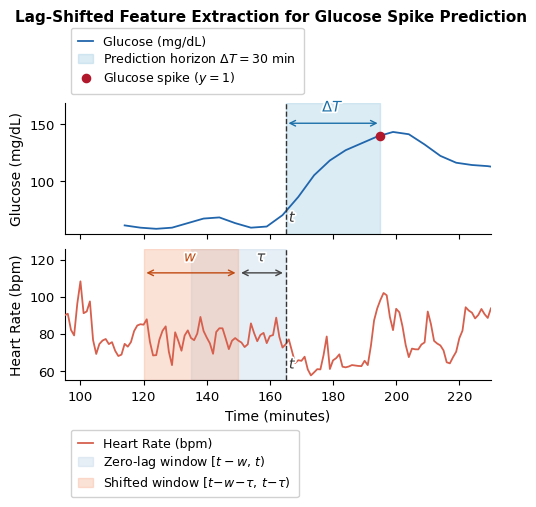

Saved figure1_lag_window.pdf and figure1_lag_window.png


In [18]:
plot_lag_window_figure(
    grid=master_data["001"]["grid"],
    t_pred=165,
    delta_T=30,
    w=30,
    lag=15,
    save_path="figure1_lag_window",
    figsize=(5.5, 3.6)
)

## A.1 Random Forest Test

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score

print("\n==============================")
print("EXPERIMENT A.1 — RANDOM FOREST ZERO LAG MODEL")
print("==============================")

# ─────────────────────────────────────────────
# LOSO evaluation
# ─────────────────────────────────────────────
print("\n Running LOSO-CV...")
y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
    full_data_no_lag,
    FEATURE_COLS,
    make_rf(),
    scale=True,
    verbose=True,
    smote=False
)

# ─────────────────────────────────────────────
# Results
# ─────────────────────────────────────────────

#y_pred = (y_prob_all >= 0.5).astype(int)

print("\n================ A.1 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")
print(f"PR-ROC (overall): {average_precision_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

rf_baseline_mean = np.mean(list(per_pid_auc.values()))
rf_baseline_std = np.std(list(per_pid_auc.values()))
print(f"\nMean AUROC: {rf_baseline_mean:.3f}")
print(f"Std AUROC:  {rf_baseline_std:.3f}")


EXPERIMENT A.1 — RANDOM FOREST ZERO LAG MODEL

 Running LOSO-CV...
Leave one out -- test_pid for this iteration: 001
Train set length: 20207
Test set length: 1611
Leave one out -- test_pid for this iteration: 002
Train set length: 20253
Test set length: 1565
Leave one out -- test_pid for this iteration: 003
Train set length: 20936
Test set length: 882
Leave one out -- test_pid for this iteration: 004
Train set length: 20905
Test set length: 913
Leave one out -- test_pid for this iteration: 005
Train set length: 20027
Test set length: 1791
Leave one out -- test_pid for this iteration: 006
Train set length: 20612
Test set length: 1206
Leave one out -- test_pid for this iteration: 007
Train set length: 20232
Test set length: 1586
Leave one out -- test_pid for this iteration: 008
Train set length: 20159
Test set length: 1659
Leave one out -- test_pid for this iteration: 009
Train set length: 20114
Test set length: 1704
Leave one out -- test_pid for this iteration: 010
Train set length: 20

In [ ]:
res_a1 = calculate_bootstrap(per_pid_auc)
all_aucrocs["A.1"] = per_pid_auc

## A.1.1 Random Forest Feature Selection

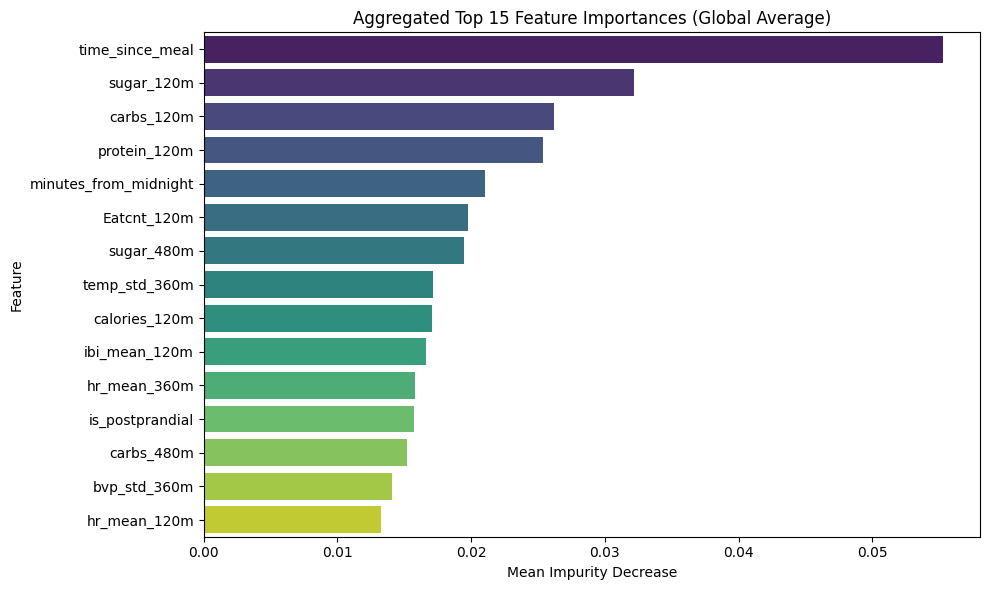

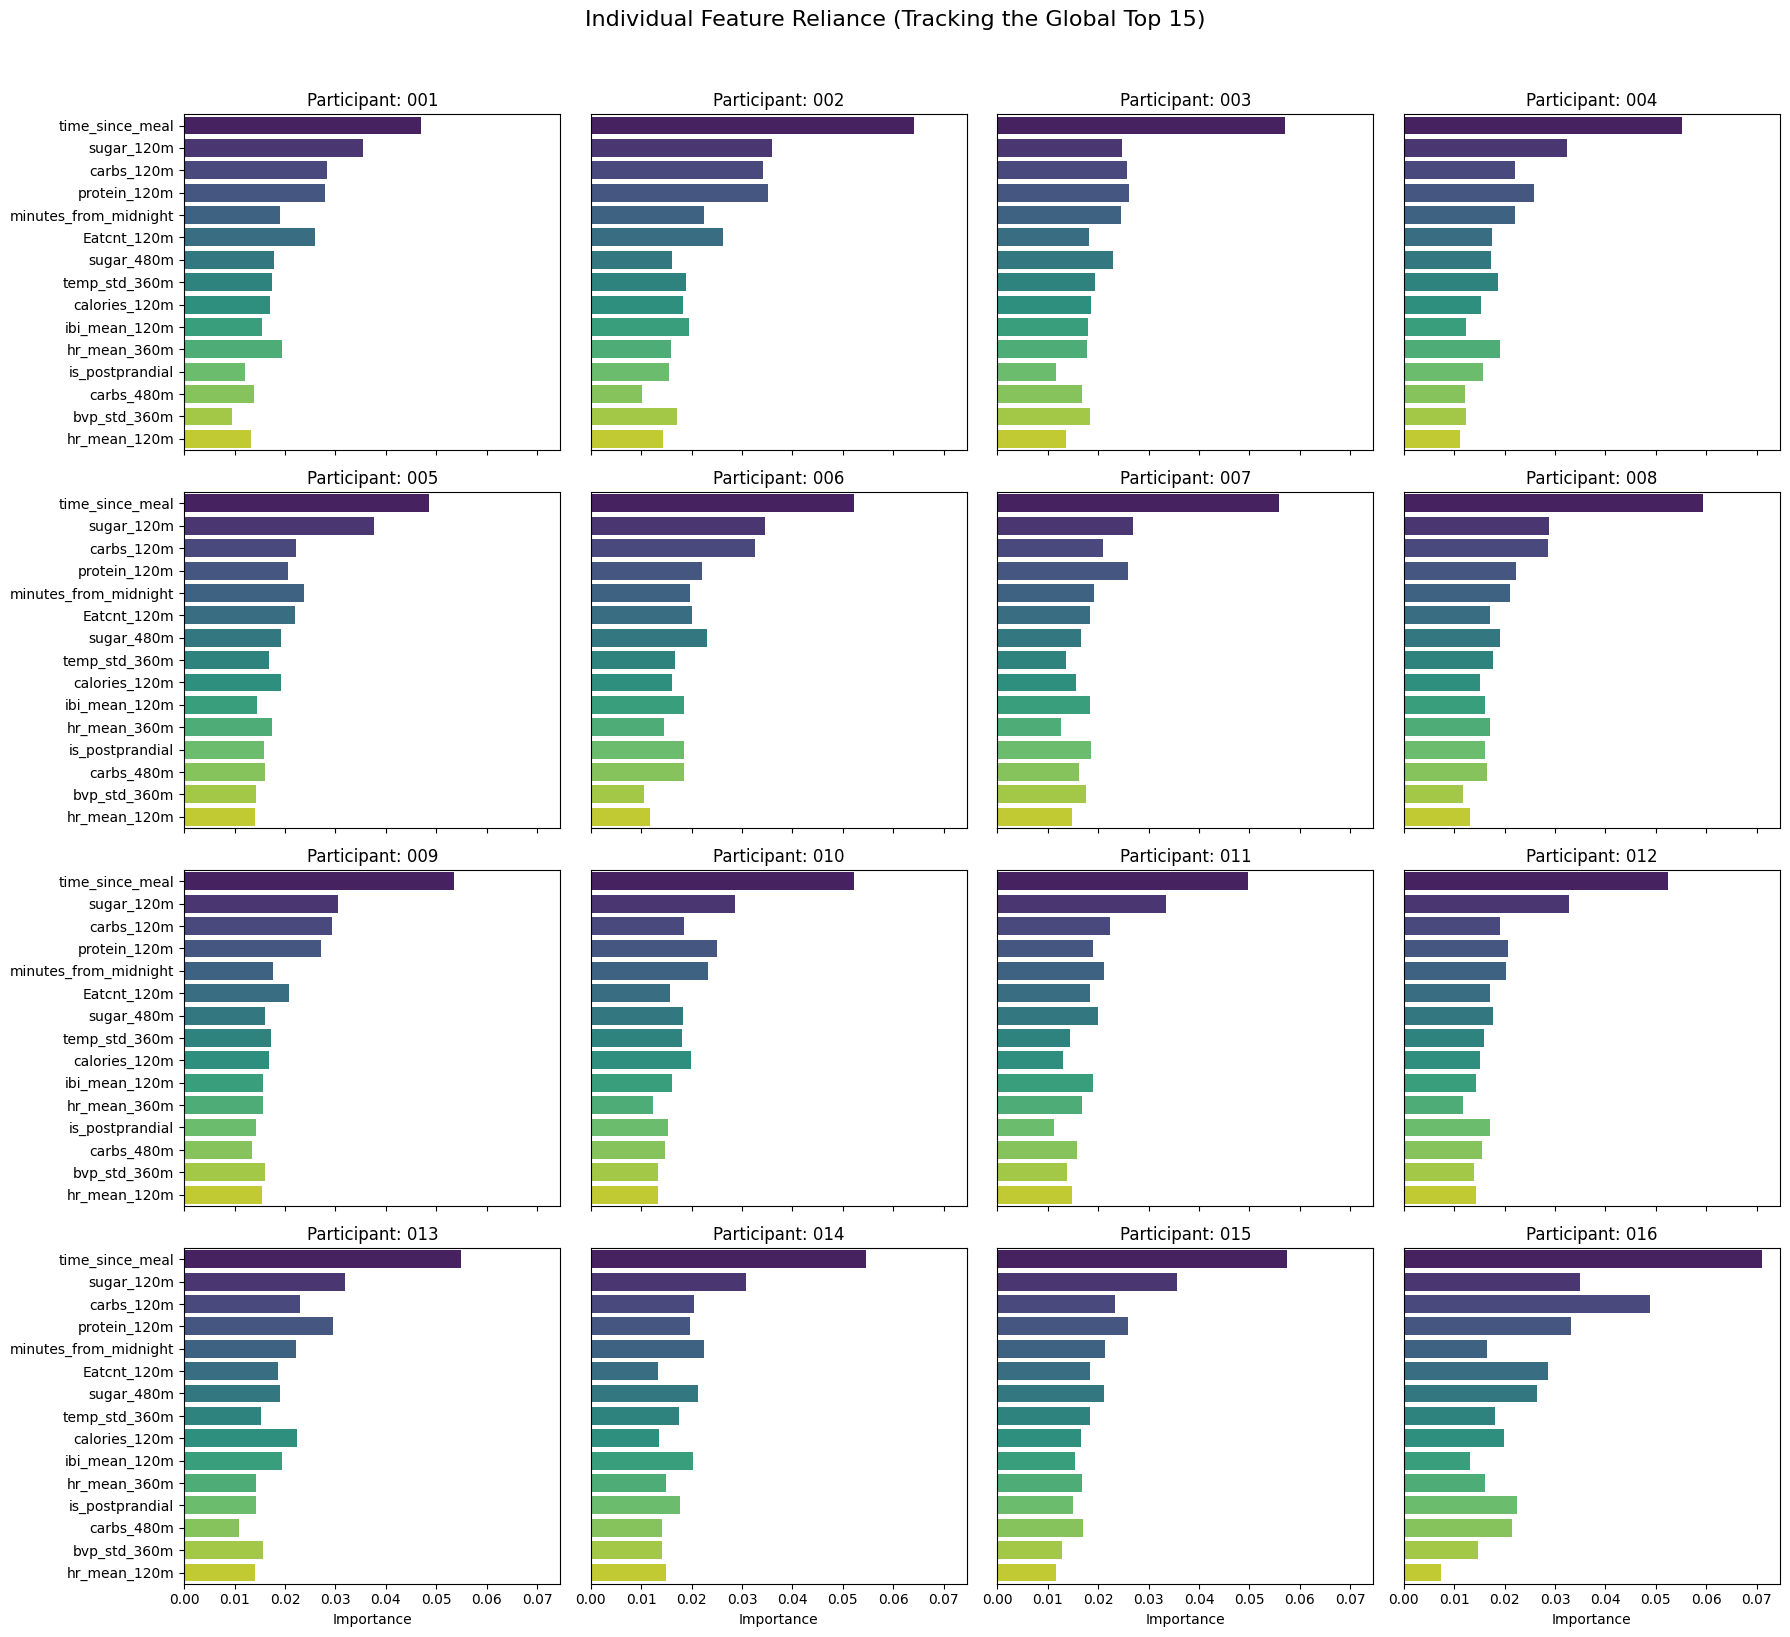

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

all_pids = full_data_no_lag["pid"].unique()
avg_importances = np.sum(all_importances, axis=0)/len(all_pids)

# --- 1. IDENTIFY THE GLOBAL TOP FEATURES ---
# Create a dataframe of the aggregated importances
global_importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Global_Importance': avg_importances
}).sort_values(by='Global_Importance', ascending=False)

# Get the names and original indices of the Top 15 features
top_n = 15
top_features = global_importance_df['Feature'].head(top_n).tolist()
top_indices = [FEATURE_COLS.index(f) for f in top_features]


# --- 2. PLOT THE AGGREGATED (GLOBAL) IMPORTANCES ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=global_importance_df.head(top_n), 
    x='Global_Importance', 
    y='Feature', 
    palette='viridis'
)
plt.title(f"Aggregated Top {top_n} Feature Importances (Global Average)")
plt.xlabel("Mean Impurity Decrease")
plt.tight_layout()
plt.show()


# --- 3. PLOT THE INDIVIDUAL GRID (APPLES-TO-APPLES) ---
num_pids = len(all_pids)
cols = 4
rows = math.ceil(num_pids / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4), sharex=True)
axes = axes.flatten()

for i, (pid, importances) in enumerate(zip(all_pids, all_importances)):
    # Extract the scores for ONLY the global top 15 features
    individual_scores = [importances[idx] for idx in top_indices]
    
    sns.barplot(x=individual_scores, y=top_features, ax=axes[i], palette='viridis')
    axes[i].set_title(f"Participant: {pid}")
    axes[i].set_xlabel("Importance")
    
    # Hide Y-axis labels on the inner plots to keep the grid clean and tight
    if i % cols != 0:
        axes[i].set_ylabel("")
        axes[i].set_yticks([])

# Clean up any empty subplots if you have a number of pids that doesn't divide by 4 perfectly
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Individual Feature Reliance (Tracking the Global Top {top_n})", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
#copied this from one of the below cells
useless_features = global_importance_df.tail(20)["Feature"].tolist()

FEATURE_COLS_RF = [f for f in FEATURE_COLS if f not in useless_features]
print(len(FEATURE_COLS_RF))

96


In [19]:
print("\n==============================")
print("EXPERIMENT A.1.1 — RANDOM FOREST ZERO LAG MODEL, FEATURE-SELECTED")
print("==============================")

# ─────────────────────────────────────────────
# LOSO evaluation
# ─────────────────────────────────────────────
print("\n Running LOSO-CV...")

y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
    full_data_no_lag,
    FEATURE_COLS_RF,
    make_rf(),
    verbose=True,
    scale=True
)

# ─────────────────────────────────────────────
# Results
# ─────────────────────────────────────────────

y_pred = (y_prob_all >= 0.5).astype(int)

print("\n================ A.1.1 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")


EXPERIMENT A.1.1 — RANDOM FOREST ZERO LAG MODEL, FEATURE-SELECTED

 Running LOSO-CV...
Leave one out -- test_pid for this iteration: 001
Train set length: 5721
Test set length: 558
Leave one out -- test_pid for this iteration: 002
Train set length: 5183
Test set length: 1096
Leave one out -- test_pid for this iteration: 003
Train set length: 6081
Test set length: 198
Leave one out -- test_pid for this iteration: 004
Train set length: 6034
Test set length: 245
Leave one out -- test_pid for this iteration: 005
Train set length: 6094
Test set length: 185
Leave one out -- test_pid for this iteration: 006
Train set length: 6139
Test set length: 140
Leave one out -- test_pid for this iteration: 007
Train set length: 5573
Test set length: 706
Leave one out -- test_pid for this iteration: 008
Train set length: 5758
Test set length: 521
Leave one out -- test_pid for this iteration: 009
Train set length: 6030
Test set length: 249
Leave one out -- test_pid for this iteration: 010
Train set lengt

In [ ]:
res_a11 = calculate_bootstrap(per_pid_auc)
all_aucrocs["A.1.1"] = per_pid_auc

## A.1.2 Ablation Study

### No Food Columns

In [24]:
FEATURE_COLS_ABLATE = []
FEATURE_COLS_ABLATE.extend(demographics)
FEATURE_COLS_ABLATE.extend(physio_cols)
FEATURE_COLS_ABLATE.append("minutes_from_midnight")
print(FEATURE_COLS_ABLATE)
print(f"Number of features for ablation study: {len(FEATURE_COLS_ABLATE)}")

['sex', 'hba1c', 'hr_mean_15m', 'hr_std_15m', 'hr_max_15m', 'hr_slope_15m', 'eda_mean_15m', 'eda_std_15m', 'eda_max_15m', 'eda_slope_15m', 'temp_mean_15m', 'temp_std_15m', 'temp_max_15m', 'temp_slope_15m', 'acc_mean_15m', 'acc_std_15m', 'acc_max_15m', 'acc_slope_15m', 'hr_mean_30m', 'hr_std_30m', 'hr_max_30m', 'hr_slope_30m', 'eda_mean_30m', 'eda_std_30m', 'eda_max_30m', 'eda_slope_30m', 'temp_mean_30m', 'temp_std_30m', 'temp_max_30m', 'temp_slope_30m', 'acc_mean_30m', 'acc_std_30m', 'acc_max_30m', 'acc_slope_30m', 'hr_mean_120m', 'hr_std_120m', 'hr_max_120m', 'hr_slope_120m', 'eda_mean_120m', 'eda_std_120m', 'eda_max_120m', 'eda_slope_120m', 'temp_mean_120m', 'temp_std_120m', 'temp_max_120m', 'temp_slope_120m', 'acc_mean_120m', 'acc_std_120m', 'acc_max_120m', 'acc_slope_120m', 'hr_mean_360m', 'hr_std_360m', 'hr_max_360m', 'hr_slope_360m', 'eda_mean_360m', 'eda_std_360m', 'eda_max_360m', 'eda_slope_360m', 'temp_mean_360m', 'temp_std_360m', 'temp_max_360m', 'temp_slope_360m', 'acc_mean_

In [25]:
print("\n==============================")
print("EXPERIMENT A.1.2 — RANDOM FOREST ZERO LAG, ABLATION")
print("==============================")

print("\n Running LOSO-CV...")
y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
    full_data_no_lag,
    FEATURE_COLS_ABLATE,
    make_rf(),
    scale=True,
    verbose=True,
    smote=False
)

#y_pred = (y_prob_all >= 0.5).astype(int)

print("\n================ A.1.2 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")
print(f"PR-ROC (overall): {average_precision_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

print(f"\nMean AUROC: {np.mean(list(per_pid_auc.values())):.3f}")
print(f"Std AUROC:  {np.std(list(per_pid_auc.values())):.3f}")


EXPERIMENT A.1.2 — RANDOM FOREST ZERO LAG, ABLATION

 Running LOSO-CV...
Leave one out -- test_pid for this iteration: 001
Train set length: 20207
Test set length: 1611
Leave one out -- test_pid for this iteration: 002
Train set length: 20253
Test set length: 1565
Leave one out -- test_pid for this iteration: 003
Train set length: 20936
Test set length: 882
Leave one out -- test_pid for this iteration: 004
Train set length: 20905
Test set length: 913
Leave one out -- test_pid for this iteration: 005
Train set length: 20027
Test set length: 1791
Leave one out -- test_pid for this iteration: 006
Train set length: 20612
Test set length: 1206
Leave one out -- test_pid for this iteration: 007
Train set length: 20232
Test set length: 1586
Leave one out -- test_pid for this iteration: 008
Train set length: 20159
Test set length: 1659
Leave one out -- test_pid for this iteration: 009
Train set length: 20114
Test set length: 1704
Leave one out -- test_pid for this iteration: 010
Train set leng

In [ ]:
res_a12 = calculate_bootstrap(per_pid_auc)
all_aucrocs["A.1.2"] = per_pid_auc

## A.2 XGBoost Test

In [23]:
print("\n==============================")
print("EXPERIMENT A.2 — XGBoost ZERO LAG MODEL")
print("==============================")

# ─────────────────────────────────────────────
# LOSO evaluation
# ─────────────────────────────────────────────
print("\n Running LOSO-CV...")

y_true_all, y_prob_all, per_pid_auc, all_importances = run_loso(
    full_data_no_lag,
    FEATURE_COLS,
    make_xgb(),
    scale=True,
    verbose=True
)

# ─────────────────────────────────────────────
# Results
# ─────────────────────────────────────────────
y_pred = (y_prob_all >= 0.5).astype(int)

print("\n================ A.2 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

xgb_baseline_mean = np.mean(list(per_pid_auc.values()))
xgb_baseline_std = np.std(list(per_pid_auc.values()))
print(f"\nMean AUROC: {xgb_baseline_mean:.3f}")
print(f"Std AUROC:  {xgb_baseline_std:.3f}")


EXPERIMENT A.2 — XGBoost ZERO LAG MODEL

 Running LOSO-CV...
Leave one out -- test_pid for this iteration: 001
Train set length: 20207
Test set length: 1611
Leave one out -- test_pid for this iteration: 002
Train set length: 20253
Test set length: 1565
Leave one out -- test_pid for this iteration: 003
Train set length: 20936
Test set length: 882
Leave one out -- test_pid for this iteration: 004
Train set length: 20905
Test set length: 913
Leave one out -- test_pid for this iteration: 005
Train set length: 20027
Test set length: 1791
Leave one out -- test_pid for this iteration: 006
Train set length: 20612
Test set length: 1206
Leave one out -- test_pid for this iteration: 007
Train set length: 20232
Test set length: 1586
Leave one out -- test_pid for this iteration: 008
Train set length: 20159
Test set length: 1659
Leave one out -- test_pid for this iteration: 009
Train set length: 20114
Test set length: 1704
Leave one out -- test_pid for this iteration: 010
Train set length: 20232
Te

In [ ]:
res_a2 = calculate_bootstrap(per_pid_auc)
all_aucrocs["A.2"] = per_pid_auc

# Experiment B -- UNFORM LAG SWEEP

In [21]:
rf_means = []
rf_stds = []

xgb_means = []
xgb_stds = []

In [22]:
lag_sweep_values = [5, 10, 15, 20, 25, 30, 45, 60]

In [26]:
from sklearn.metrics import roc_auc_score, f1_score

def perform_uniform_sweep(model, lags=[5, 10, 15, 20, 25, 30, 45, 60], features=FEATURE_COLS):
    print(f"{'Lag (min)':<12} {'AUROC':<8} {'F1-Spike':<10}")
    print("-" * 32)
    
    lag_results = {}
    per_pid_results = {}
    
    # We assume `master_data` and `FEATURE_COLS` are already loaded in memory
    for lag in lags:
        
        # 1. Build the feature dataset in memory using the cached grids
        lag_df = build_full_dataset(
            master_data, 
            tau=lag,
            physio_windows=physio_windows,
            food_windows=food_windows,
            save_csv=False # Set to True if you want to inspect each lag's CSV
        )
        
        # Safety check: if lag is so large it pushes all data to NaN
        if len(lag_df) == 0:
            print(f"{lag:<12} {'Failed: Empty dataset'}")
            continue
        
        # 2. Run LOSO-CV (ensure you pass the model and scale parameters)
        y_true, y_prob, per_pid_auc, _ = run_loso(
            dataset=lag_df, 
            feature_cols=features, 
            model=model, 
            scale=True,
            verbose=False
        )
        per_pid_results[lag] = per_pid_auc
        
        # 3. Evaluate
        if len(np.unique(y_true)) > 1:
            auc = roc_auc_score(y_true, y_prob)
            threshold=0.05
            y_pred_lag = (y_prob >= threshold).astype(int)
            f1 = f1_score(y_true, y_pred_lag)
            
            lag_results[lag] = {"auroc": auc, "f1": f1}
            
            # Suppress the massive build_full_dataset printouts during the sweep 
            # so you just get the clean table row:
            print(f"{lag:<12} {auc:<8.3f} {f1:<10.3f}")
        else:
            print(f"{lag:<12} {'Failed: Only one class present in predictions'}")
    
    # 4. Conclude
    if lag_results:
        best_lag = max(lag_results, key=lambda x: lag_results[x]["auroc"])
        print(f"\nBest uniform lag: {best_lag} minutes "
              f"(AUROC={lag_results[best_lag]['auroc']:.3f})")
    else:
        print("\nNo valid results obtained for any lag.")
    
    #check individual per_pid_results for each lag...
    if per_pid_results:
        print("="*60)
        for lag, per_pid_auc in sorted(per_pid_results.items()):
            print(f"Per-participant AUROC for {lag}:")
            for pid, auc in per_pid_auc.items():
                print(f"  {pid}: {auc:.3f}")
            print("="*60)
    else:
        print("no per pid results")

    return lag_results, per_pid_results, best_lag

## B.1 Random Forest Sweep

In [27]:
print("\n==============================")
print("EXPERIMENT B.1 — UNIFORM LAG SWEEP RANDOM FOREST")
print("==============================\n")

rf_lag_res, rf_perpid_res, rf_best_lag = perform_uniform_sweep(make_rf(), lags=lag_sweep_values, features=FEATURE_COLS)


EXPERIMENT B.1 — UNIFORM LAG SWEEP RANDOM FOREST

Lag (min)    AUROC    F1-Spike  
--------------------------------
5            0.740    0.156     
10           0.704    0.137     
15           0.657    0.124     
20           0.638    0.121     
25           0.611    0.111     
30           0.597    0.109     
45           0.601    0.110     
60           0.595    0.103     

Best uniform lag: 5 minutes (AUROC=0.740)
Per-participant AUROC for 5:
  001: 0.719
  002: 0.681
  003: 0.754
  004: 0.809
  005: 0.862
  006: 0.714
  007: 0.937
  008: 0.772
  009: 0.735
  010: 0.804
  011: 0.794
  012: 0.731
  013: 0.785
  014: 0.703
  015: 0.589
  016: 0.489
Per-participant AUROC for 10:
  001: 0.686
  002: 0.676
  003: 0.695
  004: 0.724
  005: 0.834
  006: 0.722
  007: 0.906
  008: 0.742
  009: 0.681
  010: 0.771
  011: 0.729
  012: 0.695
  013: 0.726
  014: 0.628
  015: 0.644
  016: 0.515
Per-participant AUROC for 15:
  001: 0.652
  002: 0.643
  003: 0.664
  004: 0.684
  005: 0.831
  006:

In [28]:
for lag_val in lag_sweep_values:
    per_pid_auc = rf_perpid_res[lag_val]
    rf_means.append(np.mean(list(per_pid_auc.values())))
    rf_stds.append(np.std(list(per_pid_auc.values())))
    
aucs_best = rf_perpid_res[rf_best_lag]
res_b1 = calculate_bootstrap(aucs_best)
all_aucrocs["B.1"] = aucs_best
#the overall aucroc can be found in the printout above.

Lower Bound: 0.6865
Upper Bound: 0.7859


## B.2 XGBoost Sweep

In [29]:
print("\n==============================")
print("EXPERIMENT B.2 — UNIFORM LAG SWEEP XGBOOST")
print("==============================\n")

xgb_lag_res, xgb_perpid_res, xgb_best_lag = perform_uniform_sweep(make_xgb(), lags=lag_sweep_values, features=FEATURE_COLS)


EXPERIMENT B.2 — UNIFORM LAG SWEEP XGBOOST

Lag (min)    AUROC    F1-Spike  
--------------------------------
5            0.687    0.208     
10           0.684    0.176     
15           0.631    0.131     
20           0.595    0.110     
25           0.573    0.101     
30           0.567    0.097     
45           0.572    0.099     
60           0.560    0.086     

Best uniform lag: 5 minutes (AUROC=0.687)
Per-participant AUROC for 5:
  001: 0.716
  002: 0.625
  003: 0.645
  004: 0.726
  005: 0.811
  006: 0.754
  007: 0.876
  008: 0.651
  009: 0.661
  010: 0.781
  011: 0.719
  012: 0.749
  013: 0.779
  014: 0.600
  015: 0.391
  016: 0.445
Per-participant AUROC for 10:
  001: 0.766
  002: 0.614
  003: 0.544
  004: 0.763
  005: 0.699
  006: 0.638
  007: 0.880
  008: 0.641
  009: 0.660
  010: 0.780
  011: 0.697
  012: 0.745
  013: 0.746
  014: 0.613
  015: 0.682
  016: 0.630
Per-participant AUROC for 15:
  001: 0.694
  002: 0.593
  003: 0.704
  004: 0.704
  005: 0.727
  006: 0.584

In [30]:
for lag_val in lag_sweep_values:
    per_pid_auc = xgb_perpid_res[lag_val]
    xgb_means.append(np.mean(list(per_pid_auc.values())))
    xgb_stds.append(np.std(list(per_pid_auc.values())))

    
aucs_best = xgb_perpid_res[xgb_best_lag]
res_b2 = calculate_bootstrap(aucs_best)
all_aucrocs["B.2"] = aucs_best

Lower Bound: 0.6106
Upper Bound: 0.7325


## Graphical Analysis

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe


def plot_lag_sweep_figure(
    lag_values,
    rf_means,
    rf_stds,
    xgb_means,
    xgb_stds,
    rf_baseline_mean,
    xgb_baseline_mean,
    save_path="figure_lag_sweep",
    figsize=(5.5, 3.6),
):
    """
    Publication-ready lag sweep figure for IEEE MLSP paper.

    Plots mean per-patient AUROC vs uniform lag for RF and XGBoost,
    with each model's zero-lag baseline shown as a horizontal dashed line.
    Shaded bands show ±1 std across patients.
    """

    lag_values = np.array(lag_values)
    rf_means   = np.array(rf_means)
    rf_stds    = np.array(rf_stds)
    xgb_means  = np.array(xgb_means)
    xgb_stds   = np.array(xgb_stds)

    # ── Colours ───────────────────────────────────────────────────────────────
    C_RF       = "#2166ac"   # blue  — RF
    C_XGB      = "#d6604d"   # red   — XGBoost
    C_RF_BASE  = "#2166ac"
    C_XGB_BASE = "#d6604d"

    LW_LINE  = 1.6
    LW_BASE  = 1.2
    FS_LABEL = 11
    FS_ANNOT = 9.5
    FS_AXIS  = 10
    MS       = 5             # marker size

    outline = [pe.withStroke(linewidth=2.5, foreground="white")]

    plt.rcParams['font.family'] = 'sans-serif'

    fig, ax = plt.subplots(figsize=figsize)

    # ── RF sweep line + std band ──────────────────────────────────────────────    
    ax.errorbar(lag_values, rf_means, yerr=rf_stds,
                 color=C_RF, lw=LW_LINE, marker="o", markersize=MS,
                 capsize=3, elinewidth=1.0, zorder=3, label="Random Forest (B.1)")

    # ── XGBoost sweep line + std band ─────────────────────────────────────────
    ax.errorbar(lag_values, xgb_means, yerr=xgb_stds,
                 color=C_XGB, lw=LW_LINE, marker="s", markersize=MS,
                 capsize=3, elinewidth=1.0, zorder=3, label="XGBoost (B.2)")

    # ── Baseline horizontal dashed lines ─────────────────────────────────────
    ax.axhline(rf_baseline_mean,
               color=C_RF_BASE, lw=LW_BASE, ls="--", zorder=4,
               label=f"A.1 RF baseline ({rf_baseline_mean:.3f})")
    ax.axhline(xgb_baseline_mean,
               color=C_XGB_BASE, lw=LW_BASE, ls=":",  zorder=4,
               label=f"A.2 XGBoost baseline ({xgb_baseline_mean:.3f})")

    # ── Baseline value labels on right edge ───────────────────────────────────
    x_right = lag_values[-1]
    y_offset = 0.01
    ax.text(x_right + 0.8, rf_baseline_mean+y_offset,
            f"{rf_baseline_mean:.3f}",
            ha="left", va="center",
            fontsize=FS_ANNOT, color=C_RF_BASE,
            path_effects=outline)
    ax.text(x_right + 0.8, xgb_baseline_mean+y_offset,
            f"{xgb_baseline_mean:.3f}",
            ha="left", va="center",
            fontsize=FS_ANNOT, color=C_XGB_BASE,
            path_effects=outline)

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xlabel("Uniform Lag $\\tau$ (minutes)", fontsize=FS_LABEL)
    ax.set_ylabel("Mean Per-Patient AUROC", fontsize=FS_LABEL)
    ax.set_xticks(lag_values)
    ax.tick_params(axis="both", labelsize=FS_AXIS)
    ax.set_xlim(lag_values[0] - 1, lag_values[-1] + 5)   # right margin for labels

    # y-axis range: tight around the data with a little padding
    all_vals = np.concatenate([
        rf_means - rf_stds, rf_means + rf_stds,
        xgb_means - xgb_stds, xgb_means + xgb_stds,
        [rf_baseline_mean, xgb_baseline_mean]
    ])
    y_lo = np.nanmin(all_vals) - 0.02
    y_hi = np.nanmax(all_vals) + 0.02
    ax.set_ylim(y_lo, y_hi)

    ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2,
          fontsize=FS_ANNOT, framealpha=0.90, handlelength=1.6,
          borderpad=0.5, labelspacing=0.3, columnspacing=1.0)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.suptitle(
        "Uniform Lag Sweep vs Zero-Lag Baseline",
        fontsize=FS_LABEL + 2, fontweight="bold", y=1.18
    )

    fig.savefig(f"{save_path}.pdf", bbox_inches="tight", format="pdf")
    fig.savefig(f"{save_path}.png", dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}.pdf and {save_path}.png")

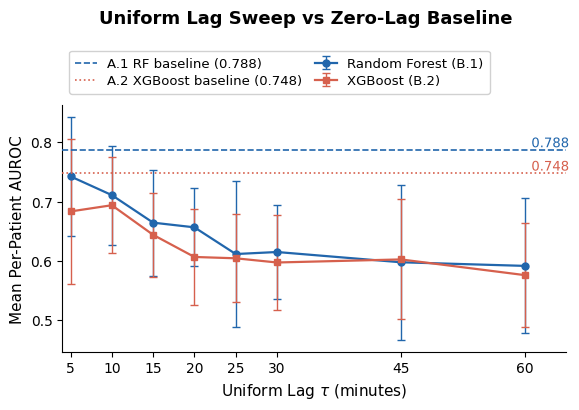

Saved figure_lag_sweep.pdf and figure_lag_sweep.png


In [35]:
plot_lag_sweep_figure(
    lag_values=lag_sweep_values,
    rf_means=rf_means,
    rf_stds=rf_stds,
    xgb_means=xgb_means,
    xgb_stds=xgb_stds,
    rf_baseline_mean=rf_baseline_mean,
    xgb_baseline_mean=xgb_baseline_mean,
    save_path="figure_lag_sweep",
    figsize=(6.5, 3.2)
)

# Experiment C -- Custom Lag

In [19]:
# ─────────────────────────────────────────────────────────────
# EVENT-ALIGNED LAG COMPUTATION
# ─────────────────────────────────────────────────────────────

def compute_event_aligned_lag(grids_and_labels, mod, max_lag=30, pre_window=5):
    """
    Compute population-level lag for a single modality using spike-event alignment.
    
    For each spike event across all (training) patients, compute the rate of change
    (slope) of the signal in a small window around t-lag, for each candidate lag.
    The best lag is where the average absolute slope is highest — i.e. where the
    signal is most consistently changing in the minutes before a spike.

    Parameters
    ----------
    grids_and_labels : list of (grid, labels_df) tuples
        Only pass training patients' data to avoid leakage.
    mod : str
        Modality column name in grid (e.g. 'hr', 'eda', 'temp', 'acc')
    max_lag : int
        Maximum lag to search in minutes
    pre_window : int
        Half-window size in minutes for slope computation around each lag point.
        Slope is computed over [t - lag - pre_window, t - lag + pre_window].

    Returns
    -------
    best_lag : int
        Lag in minutes where signal shows strongest pre-spike activity.
    lag_scores : np.ndarray
        Full score array for all lags (useful for plotting/debugging).
    n_events : int
        Number of spike events used in the computation.
    """
    lag_scores = np.zeros(max_lag + 1)
    n_contributing = np.zeros(max_lag + 1)  # track how many events contributed to each lag

    for grid, labels_df in grids_and_labels:
        if mod not in grid.columns:
            continue

        signal = grid[mod]
        spike_minutes = labels_df[labels_df["label"] == 1]["minute"].values

        for t in spike_minutes:
            for lag in range(0, max_lag + 1):
                # Center of the slope window, shifted back by lag
                center = t - lag

                # Extract the small window around center
                w_start = center - pre_window
                w_end   = center + pre_window

                # Bounds check
                if w_start < grid.index.min() or w_end > grid.index.max():
                    continue

                window_vals = signal.loc[w_start:w_end].dropna()

                if len(window_vals) < 3:
                    continue

                # Slope via linear regression over the window
                x = np.arange(len(window_vals))
                y = window_vals.values
                
                # np.polyfit degree 1 = linear, returns [slope, intercept]
                slope = np.polyfit(x, y, 1)[0]

                # Normalize slope by signal std to make comparable across modalities
                signal_std = signal.std()
                if signal_std > 1e-6:
                    normalized_slope = abs(slope) / signal_std
                else:
                    continue

                lag_scores[lag]      += normalized_slope
                n_contributing[lag]  += 1

    # Average across contributing events to avoid bias toward lags with more data
    with np.errstate(divide="ignore", invalid="ignore"):
        avg_scores = np.where(
            n_contributing > 0,
            lag_scores / n_contributing,
            0
        )

    best_lag = int(np.argmax(avg_scores))
    n_events = int(n_contributing[0])  # lag=0 has the most contributors, use as total

    return best_lag, avg_scores, n_events


def compute_population_lags(grids_and_labels, modalities, max_lag=30, pre_window=5, verbose=True):
    """
    Compute one lag per modality across all provided patients.

    Parameters
    ----------
    grids_and_labels : list of (grid, labels_df)
    modalities : list of str
    
    Returns
    -------
    lag_dict : dict  {modality: lag_minutes}
    """
    lag_dict = {}

    if verbose:
        print(f"\n  {'Modality':<10} {'Lag':>6}  {'Events':>8}")
        print(f"  {'-'*30}")

    for mod in modalities:
        best_lag, scores, n_events = compute_event_aligned_lag(
            grids_and_labels,
            mod=mod,
            max_lag=max_lag,
            pre_window=pre_window
        )
        lag_dict[mod] = best_lag

        if verbose:
            print(f"  {mod:<10} {best_lag:>6}  {n_events:>8}")

    return lag_dict


# ─────────────────────────────────────────────────────────────
# UPDATED LOSO LOOP FOR EXPERIMENT C
# ─────────────────────────────────────────────────────────────
def build_with_demographics(pid, tau, master_data, physio_windows, food_windows):
    feat_df = build_feature_matrix(
        grid=master_data[pid]["grid"],
        labels_df=master_data[pid]["labels"],
        tau=tau,
        physio_windows=physio_windows,
        food_windows=food_windows
    )
    idx = int(pid)
    patient_row = demo_df[demo_df["ID"] == idx]
    if not patient_row.empty:
        feat_df["hba1c"] = patient_row["HbA1c"].values[0]
        feat_df["sex"]   = 1 if str(patient_row["Gender"].values[0]).strip().upper() == "MALE" else 0
    else:
        feat_df["hba1c"] = np.nan
        feat_df["sex"]   = np.nan
    feat_df["pid"] = pid
    return feat_df
    
def run_loso_with_event_lag(master_data, feature_cols, model, modalities,
                             physio_windows, food_windows,
                             max_lag=30, pre_window=5,
                             scale=True, verbose=False):
    """
    LOSO loop that computes event-aligned population lags fresh on each fold's
    training set, then applies them to the test patient's feature extraction.

    Lags are computed from training patients only — test patient's labels
    never influence their own feature extraction (no leakage).
    """
    all_pids = list(master_data.keys())

    y_true_all      = []
    y_prob_all      = []
    per_pid_auc     = {}
    all_importances = []
    fold_lags       = {}

    for test_pid in all_pids:
        if verbose:
            print(f"\n── LOSO fold: test={test_pid} ──")

        # 1. Split
        train_pids = [p for p in all_pids if p != test_pid]

        # 2. Compute event-aligned lags from training patients only
        train_grids_labels = [
            (master_data[p]["grid"], master_data[p]["labels"])
            for p in train_pids
        ]

        lags = compute_population_lags(
            train_grids_labels,
            modalities=modalities,
            max_lag=max_lag,
            pre_window=pre_window,
            verbose=verbose
        )
        fold_lags[test_pid] = lags

        if verbose:
            print(f"  Lags for this fold: {lags}")

        train_tables = [build_with_demographics(p, lags, master_data, physio_windows, food_windows) for p in train_pids]
        train_df     = pd.concat(train_tables, ignore_index=True)
        test_df      = build_with_demographics(test_pid, lags, master_data, physio_windows, food_windows)

        # 4. Drop NaNs on feature cols
        train_df = train_df.dropna(subset=feature_cols)
        test_df  = test_df.dropna(subset=feature_cols)

        if len(train_df) == 0 or len(test_df) == 0:
            print(f"  Skipping {test_pid}: empty train or test after dropna")
            continue

        X_train = train_df[feature_cols].values
        y_train = train_df["label"].values
        X_test  = test_df[feature_cols].values
        y_test  = test_df["label"].values

        if isinstance(model, XGBClassifier):
            ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
            model.set_params(scale_pos_weight=ratio)

        if scale:
            scaler  = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

        model.fit(X_train, y_train)
        all_importances.append(model.feature_importances_)

        y_prob = model.predict_proba(X_test)[:, 1]

        y_true_all.extend(y_test)
        y_prob_all.extend(y_prob)

        if len(np.unique(y_test)) > 1:
            auc = roc_auc_score(y_test, y_prob)
            per_pid_auc[test_pid] = auc
            if verbose:
                print(f"  AUROC: {auc:.3f}")
        else:
            if verbose:
                print(f"  Skipping AUROC for {test_pid}: only one class in test set")

    return (
        np.array(y_true_all),
        np.array(y_prob_all),
        per_pid_auc,
        all_importances,
        fold_lags
    )

## Random Forest Test

In [26]:
MODALITIES_C = ["hr", "eda", "temp", "acc"]

print("\n==============================")
print("EXPERIMENT C.1 — RANDOM FOREST w/ EVENT-ALIGNED POPULATION LAG")
print("==============================")

rf_c = make_rf()

y_true_all, y_prob_all, per_pid_auc, all_importances, fold_lags = run_loso_with_event_lag(
    master_data=master_data,
    feature_cols=FEATURE_COLS,
    model=rf_c,
    modalities=MODALITIES_C,
    physio_windows=physio_windows,
    food_windows=food_windows,
    max_lag=30,
    pre_window=5,
    scale=True,
    verbose=True
)

y_pred = (y_prob_all >= 0.5).astype(int)

print(f"\n================ C.1 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

rf_mean_c1 = np.mean(list(per_pid_auc.values()))
rf_std_c1 = np.std(list(per_pid_auc.values()))
print(f"\nMean AUROC: {rf_mean_c1:.3f}")
print(f"Std AUROC:  {rf_std_c1:.3f}")

print(f"\nLags used per fold:")
for test_pid, lags in fold_lags.items():
    print(f"  {test_pid}: {lags}")


EXPERIMENT C.1 — RANDOM FOREST w/ EVENT-ALIGNED POPULATION LAG

── LOSO fold: test=001 ──

  Modality      Lag    Events
  ------------------------------
  hr             30      1319
  eda            18      1319
  temp           27      1315
  acc            17      1319
  Lags for this fold: {'hr': 30, 'eda': 18, 'temp': 27, 'acc': 17}
  AUROC: 0.607

── LOSO fold: test=002 ──

  Modality      Lag    Events
  ------------------------------
  hr             30      1270
  eda            18      1270
  temp           27      1266
  acc            12      1270
  Lags for this fold: {'hr': 30, 'eda': 18, 'temp': 27, 'acc': 12}
  AUROC: 0.652

── LOSO fold: test=003 ──

  Modality      Lag    Events
  ------------------------------
  hr             23      1327
  eda            18      1327
  temp           23      1326
  acc             6      1327
  Lags for this fold: {'hr': 23, 'eda': 18, 'temp': 23, 'acc': 6}
  AUROC: 0.767

── LOSO fold: test=004 ──

  Modality      Lag    Events


In [ ]:
res_c1 = calculate_bootstrap(per_pid_auc)
all_aucrocs["C.1"] = per_pid_auc

### Lag Scores Observation

In [ ]:
# After one call to compute_event_aligned_lag, plot avg_scores

train_grids_labels = [
    (master_data[p]["grid"], master_data[p]["labels"])
    for p in list(master_data.keys()) if p != "001"
]

for mod in ["hr", "eda", "temp", "acc"]:
    _, scores, n_events = compute_event_aligned_lag(
        train_grids_labels, mod=mod, max_lag=30, pre_window=5
    )
    plt.plot(scores, label=mod)

plt.xlabel("Lag (minutes)")
plt.ylabel("Avg normalized slope")
plt.grid(alpha=0.3)
plt.title("Event-aligned lag scores (fold: test=001)", fontweight="bold")
plt.legend()

plt.savefig(f"lagscores.pdf", dpi=300, bbox_inches="tight", format="pdf")
plt.savefig(f"lagscores.png", dpi=300, bbox_inches="tight")
plt.show()

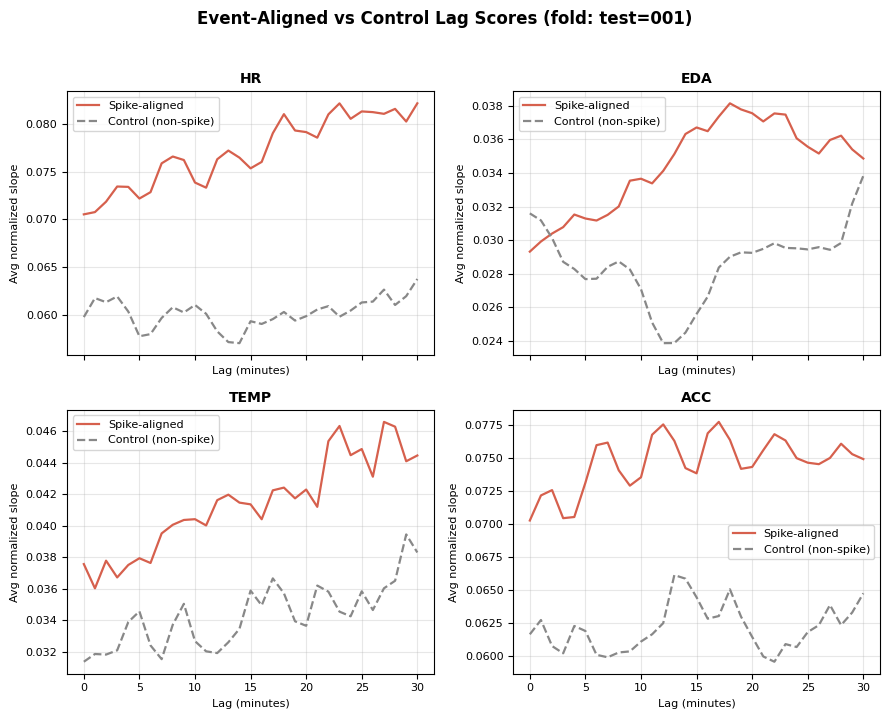

In [21]:
# Define the control function first (paste this above, once)

def compute_control_aligned_lag(grids_and_labels, mod, max_lag=30, pre_window=5,
                                   n_controls_per_patient=100, seed=42):
    rng = np.random.default_rng(seed)
    lag_scores = np.zeros(max_lag + 1)
    n_contributing = np.zeros(max_lag + 1)

    for grid, labels_df in grids_and_labels:
        if mod not in grid.columns:
            continue

        signal = grid[mod]
        non_spike_minutes = labels_df[labels_df["label"] == 0]["minute"].values

        if len(non_spike_minutes) == 0:
            continue

        sampled = rng.choice(non_spike_minutes,
                              size=min(n_controls_per_patient, len(non_spike_minutes)),
                              replace=False)

        for t in sampled:
            for lag in range(0, max_lag + 1):
                center = t - lag
                w_start = center - pre_window
                w_end   = center + pre_window

                if w_start < grid.index.min() or w_end > grid.index.max():
                    continue

                window_vals = signal.loc[w_start:w_end].dropna()
                if len(window_vals) < 3:
                    continue

                x = np.arange(len(window_vals))
                y = window_vals.values
                slope = np.polyfit(x, y, 1)[0]

                signal_std = signal.std()
                if signal_std > 1e-6:
                    normalized_slope = abs(slope) / signal_std
                else:
                    continue

                lag_scores[lag]     += normalized_slope
                n_contributing[lag] += 1

    with np.errstate(divide="ignore", invalid="ignore"):
        avg_scores = np.where(n_contributing > 0, lag_scores / n_contributing, 0)

    return avg_scores


# ── Modified plotting block ────────────────────────────────────────────────────
train_grids_labels = [
    (master_data[p]["grid"], master_data[p]["labels"])
    for p in list(master_data.keys()) if p != "001"
]

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True)
axes = axes.flatten()

for i, mod in enumerate(["hr", "eda", "temp", "acc"]):
    _, spike_scores, n_events = compute_event_aligned_lag(
        train_grids_labels, mod=mod, max_lag=30, pre_window=5
    )
    control_scores = compute_control_aligned_lag(
        train_grids_labels, mod=mod, max_lag=30, pre_window=5,
        n_controls_per_patient=100, seed=42
    )

    ax = axes[i]
    ax.plot(spike_scores, label="Spike-aligned", color="#d6604d", lw=1.6)
    ax.plot(control_scores, label="Control (non-spike)", color="#888888",
            lw=1.6, ls="--")
    ax.set_title(mod.upper(), fontsize=10, fontweight="bold")
    ax.set_xlabel("Lag (minutes)", fontsize=8)
    ax.set_ylabel("Avg normalized slope", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Event-Aligned vs Control Lag Scores (fold: test=001)",
              fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("lagscores_control.pdf", dpi=300, bbox_inches="tight", format="pdf")
plt.savefig("lagscores_control.png", dpi=600, bbox_inches="tight")
plt.show()

## XGBoost Test

In [ ]:
print("\n==============================")
print("EXPERIMENT C.2 — XGBOOST w/ EVENT-ALIGNED POPULATION LAG")
print("==============================")

xgb_c = make_xgb()

y_true_all, y_prob_all, per_pid_auc, all_importances, fold_lags = run_loso_with_event_lag(
    master_data=master_data,
    feature_cols=FEATURE_COLS,
    model=xgb_c,
    modalities=MODALITIES_C,
    physio_windows=physio_windows,
    food_windows=food_windows,
    max_lag=30,
    pre_window=5,
    scale=True,
    verbose=False
)

print(f"\n================ C.2 RESULTS ================")
print(f"AUROC (overall): {roc_auc_score(y_true_all, y_prob_all):.3f}")

print("\nPer-participant AUROC:")
for pid, auc in per_pid_auc.items():
    print(f"  {pid}: {auc:.3f}")

xgb_mean_c2 = np.mean(list(per_pid_auc.values()))
xgb_std_c2 = np.std(list(per_pid_auc.values()))
print(f"\nMean AUROC: {xgb_mean_c2:.3f}")
print(f"Std AUROC:  {xgb_std_c2:.3f}")

print(f"\nLags used per fold:")
for test_pid, lags in fold_lags.items():
    print(f"  {test_pid}: {lags}")

In [ ]:
res_c2 = calculate_bootstrap(per_pid_auc)
all_aucrocs["C.2"] = per_pid_auc

## Graphical Analysis

In [ ]:
def plot_baseline_vs_c2_bar(
    rf_baseline_mean, rf_baseline_std,
    xgb_baseline_mean, xgb_baseline_std,
    rf_mean_c1, rf_std_c1,
    xgb_mean_c2, xgb_std_c2,
    save_path="figure_baseline_vs_c2",
    figsize=(5.5, 3.6),
):
    """
    Bar plot comparing A.1/A.2 baselines vs C.2 condition for RF and XGBoost.
    Error bars show ±1 std across patients.
    """

    C_RF  = "#2166ac"
    C_XGB = "#d6604d"

    FS_LABEL = 11
    FS_ANNOT = 9.5
    FS_AXIS  = 10

    plt.rcParams['font.family'] = 'sans-serif'

    fig, ax = plt.subplots(figsize=figsize)

    groups = ["Baseline", "C.2"]
    x = np.arange(len(groups))
    bar_width = 0.35

    rf_means  = [rf_baseline_mean, rf_mean_c1]
    rf_stds   = [rf_baseline_std, rf_std_c1]
    xgb_means = [xgb_baseline_mean, xgb_mean_c2]
    xgb_stds  = [xgb_baseline_std, xgb_std_c2]

    ax.bar(x - bar_width / 2, rf_means, bar_width, yerr=rf_stds,
           color=C_RF, alpha=0.85, capsize=4, error_kw={"elinewidth": 1.2},
           label="Random Forest", zorder=3)
    ax.bar(x + bar_width / 2, xgb_means, bar_width, yerr=xgb_stds,
           color=C_XGB, alpha=0.85, capsize=4, error_kw={"elinewidth": 1.2},
           label="XGBoost", zorder=3)

    # ── Value labels above bars ───────────────────────────────────────────────
    for xi, (m, s) in zip(x - bar_width / 2, zip(rf_means, rf_stds)):
        ax.text(xi, m + s + 0.015, f"{m:.3f}",
                ha="center", va="bottom", fontsize=FS_ANNOT, color=C_RF)
    for xi, (m, s) in zip(x + bar_width / 2, zip(xgb_means, xgb_stds)):
        ax.text(xi, m + s + 0.015, f"{m:.3f}",
                ha="center", va="bottom", fontsize=FS_ANNOT, color=C_XGB)

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=FS_AXIS)
    ax.set_ylabel("Mean Per-Patient AUROC", fontsize=FS_LABEL)
    ax.tick_params(axis="both", labelsize=FS_AXIS)

    all_vals = np.concatenate([
        np.array(rf_means) + np.array(rf_stds),
        np.array(xgb_means) + np.array(xgb_stds),
    ])
    ax.set_ylim(0, np.nanmax(all_vals) + 0.08)

    ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2,
              fontsize=FS_ANNOT, framealpha=0.90, handlelength=1.6,
              borderpad=0.5, labelspacing=0.3, columnspacing=1.0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.suptitle(
        "Baseline vs. Modality-Specific Lag",
        fontsize=FS_LABEL + 2, fontweight="bold", y=1.18
    )

    fig.savefig(f"{save_path}.pdf", bbox_inches="tight", format="pdf")
    fig.savefig(f"{save_path}.png", dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}.pdf and {save_path}.png")

In [ ]:
plot_baseline_vs_c2_bar(
    rf_baseline_mean,
    rf_baseline_std,
    xgb_baseline_mean,
    xgb_baseline_std,
    rf_mean_c1,
    rf_std_c1,
    xgb_mean_c2,
    xgb_std_c2,
    save_path="figure_baseline_vs_c"
)

# Statistical Analysis

## Table 2 Statistical Comparisons

In [ ]:
from scipy.stats import wilcoxon

def wilcoxon_with_effect(a, b):
    stat, p = wilcoxon(a, b)
    n = len(a)
    r = 1 - (4 * stat) / (n * (n + 1)) #kerby 2014 matched-pairs rank-biserial correlation
    return stat, p, r

# Run all six comparisons
comparisons = [
    ("A.1", "B.1"),
    ("A.2", "B.2"),
    ("A.1", "C.1"),
    ("A.2", "C.2"),
    ("A.1", "A.1.1"), #zero lag rf vs feature selected
    ("A.1", "A.1.2"), #zero lag rf vs no food
    ("A.1", "A.2")
]

for a, b in comparisons:
    name = f"{a} vs {b}"
    
    pids   = sorted(all_aucrocs[a].keys())
    aucs_a = np.array([all_aucrocs[a][p] for p in pids])
    aucs_b = np.array([all_aucrocs[b][p] for p in pids])
    
    stat, p, r = wilcoxon_with_effect(aucs_a, aucs_b)
    print(f"{name}: W={stat:.1f}, p={p:.3f}, r={r:.2f}")